<!-- ✅ UNIVERSITY LOGO — replace src with your logo URL or base64 -->
  <img src="https://cdn.remotexs.co/institute-logos/uz.png"
       alt="University Logo"
       style="height:300px; width:auto; margin-bottom:auto; display:block; margin-left:auto; margin-right:auto;">  
# Financial Econometrics Project: Apple Inc. Stock Data Analysis

## Assignment 1: Challenges in Time Series Modeling

### Student Details:

*   **Name:** MARTHA CHARANGWA R
*   **Registration Number:** R2424205
*   **Program:** HDSC
*   **Course Code:** HASTS21

# Financial Econometrics Project: Apple Inc. Stock Data Analysis

Assignment 1: Challenges in Time Series Modeling

four key issues: Skewness, Sensitivity to Outliers, Multicollinearity and lack of interpretation , detailing their definitions, effects, and potential solutions.

In [5]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

print('Libraries imported successfully.')

Libraries imported successfully.


In [6]:
# Define the ticker symbol for Apple Inc.
ticker_symbol = 'AAPL'

# Define the start and end dates for data download
start_date = '2018-01-01'
end_date = '2025-12-31'

print(f"Ticker Symbol: {ticker_symbol}")
print(f"Date Range: {start_date} to {end_date}")

Ticker Symbol: AAPL
Date Range: 2018-01-01 to 2025-12-31


In [ ]:
# Download the data
aapl_data = yf.download(ticker_symbol, start=start_date, end=end_date)

# Ensure the index is a DatetimeIndex for time series operations
aapl_data.index = pd.to_datetime(aapl_data.index)

# Flatten MultiIndex columns if they exist after download to simplify access
if isinstance(aapl_data.columns, pd.MultiIndex):
    aapl_data.columns = aapl_data.columns.droplevel(1)

print('Data downloaded successfully.')

In [8]:
# Display the first 5 rows of the DataFrame
display(aapl_data.head())

Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.304180,40.313541,39.602261,39.812839,102223600
2018-01-03,40.297153,40.839972,40.233983,40.367346,118071600
2018-01-04,40.484337,40.587286,40.262063,40.369689,89738400
2018-01-05,40.945244,41.031813,40.488998,40.580247,94640000
2018-01-08,40.793190,41.087995,40.694918,40.793190,82271200


## Challenge 1: Skewness

### Definition

Skewness is a measure of the asymmetry of the probability distribution of a real-valued random variable about its mean. A distribution, or dataset, is said to be *skewed* if it is not symmetric. The formula for sample skewness is:

$$g_1 = \frac{m_3}{m_2^{3/2}} = \frac{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^3}{\left(\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2\right)^{3/2}}$$

where $m_k$ is the k-th central moment, $n$ is the number of data points, $x_i$ are the individual data points, and $\bar{x}$ is the sample mean. Positive skewness indicates a distribution with an asymmetric tail extending toward more positive values, while negative skewness indicates a tail extending toward more negative values. (Source 1)

### Description

Skewness describes how unevenly data points are distributed around their average. In financial data, positive skewness implies a higher frequency of small gains and a few large losses, whereas negative skewness suggests frequent small losses and a few large gains. (Source 1)

### Demonstration: Numerical Example using Apple Inc. Stock Returns

The daily percentage returns from the 'Close' price of Apple Inc. stock and then compute its skewness. Stock returns often exhibit skewness, which is important for risk assessment.

In [9]:
import yfinance as yf
import pandas as pd

# Calculate daily returns from the 'Close' price
# Ensure aapl_data is defined, re-download if necessary (e.g., if kernel restarted or cells run out of order)
if 'aapl_data' not in globals():
    print("Warning: 'aapl_data' not found in current session. Attempting to re-download.")
    # Re-define necessary variables for yf.download
    import yfinance as yf # Added yfinance import here
    import pandas as pd # Added pandas import here
    ticker_symbol = 'AAPL'
    start_date = '2018-01-01'
    end_date = '2025-12-31'

    aapl_data = yf.download(ticker_symbol, start=start_date, end=end_date)
    aapl_data.index = pd.to_datetime(aapl_data.index)
    if isinstance(aapl_data.columns, pd.MultiIndex):
        aapl_data.columns = aapl_data.columns.droplevel(1)
    print('Data re-downloaded successfully.')

aapl_data['Daily_Return'] = aapl_data['Close'].pct_change() * 100

# Drop the first NaN value resulting from pct_change()
daily_returns = aapl_data['Daily_Return'].dropna()

# Calculate skewness
skewness_value = daily_returns.skew()

print(f"Number of data points: {len(daily_returns)}")
print(f"Mean Daily Return: {daily_returns.mean():.4f}%")
print(f"Median Daily Return: {daily_returns.median():.4f}%")
print(f"Skewness of Apple Inc. Daily Returns: {skewness_value:.4f}")
if skewness_value > 0:
    print("Interpretation: Positive skew — tail extends to the right (more extreme gains than losses).")
elif skewness_value < 0:
    print("Interpretation: Negative skew — tail extends to the left (more extreme losses than gains).")
else:
    print("Interpretation: Symmetric distribution.")

Number of data points: 2009
Mean Daily Return: 0.1140%
Median Daily Return: 0.1187%
Skewness of Apple Inc. Daily Returns: 0.1548
Interpretation: Positive skew — tail extends to the right (more extreme gains than losses).


### Diagram: Visual Example using Apple Inc. Stock Return


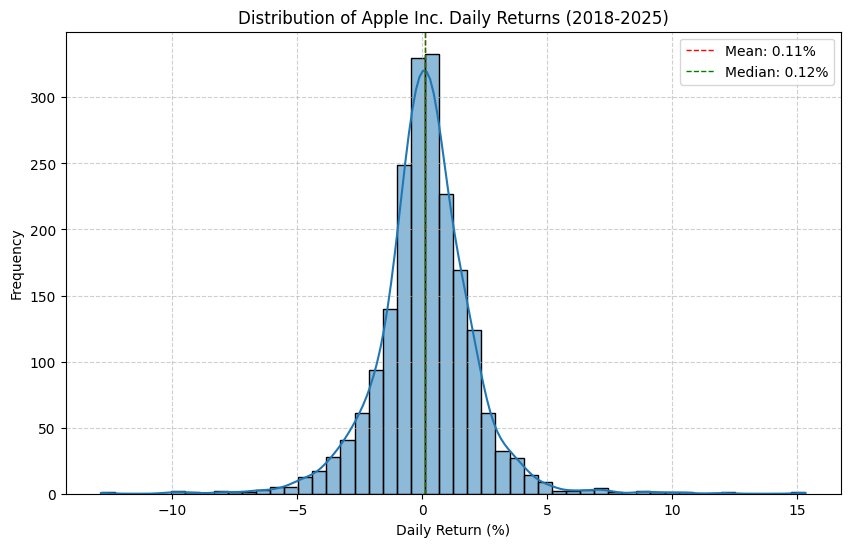

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(daily_returns, kde=True, bins=50)
plt.title('Distribution of Apple Inc. Daily Returns (2018-2025)')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.axvline(daily_returns.mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {daily_returns.mean():.2f}%')
plt.axvline(daily_returns.median(), color='green', linestyle='dashed', linewidth=1, label=f'Median: {daily_returns.median():.2f}%')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Diagnosis: How to recognize or test that the problem exists

1.  **Numerical Skewness Coefficient:** Calculate the skewness coefficient using statistical functions (e.g., `pandas.Series.skew()`). A value significantly different from zero (e.g., typically beyond \(-0.5\) to \(0.5\) or \(-1\) to \(1\) depending on context) indicates skewness.
2.  **Histogram/Density Plot:** Visually inspect the distribution of the data using a histogram or kernel density estimate (KDE) plot. A symmetric distribution will have both tails approximately equal in length and shape. A skewed distribution will show one tail longer or fatter than the other.
3.  **Mean vs. Median:** In a perfectly symmetric distribution, the mean and median are equal. If the mean is greater than the median, the distribution is positively (right) skewed. If the mean is less than the median, it is negatively (left) skewed.

### Damage: Clear statement of the damage caused by the problem

Skewness in financial time series can significantly impact the validity of statistical inferences and the performance of models. It can lead to:

1.  **Incorrect Risk Assessment:** Many traditional risk metrics (e.g., Value at Risk, standard deviation) assume normal distribution. Skewed returns can underestimate downside risk (negative skew) or overestimate upside potential, leading to flawed portfolio decisions.
2.  **Biased Model Parameters:** Skewed data can bias model parameter estimates, especially for models that assume symmetric error distributions (e.g., Ordinary Least Squares regression). This can result in inaccurate forecasts or ineffective hedging strategies.
3.  **Ineffective Statistical Tests:** Hypothesis tests that rely on assumptions of normality (e.g., t-tests, ANOVA) can produce unreliable p-values and confidence intervals when data is significantly skewed, leading to incorrect conclusions about relationships between variables.
4.  **Misleading Performance Metrics:** Performance measures like the Sharpe Ratio can be misleading for skewed return distributions, as they penalize downside risk and reward upside potential equally, even if the distribution of returns is asymmetric.

### Non-Technical: Skewness

1.  **Explanation of Results:** Our analysis of Apple Inc.'s daily returns revealed a slight positive skew (0.1548), indicating that the stock has experienced more frequent small gains and fewer, but potentially larger, losses. The histogram visibly confirms this asymmetry.
2.  **Recommended Course of Action:** To account for this, investors and analysts should consider using statistical models that can handle skewed data, like GARCH models adapted for skewed distributions, or employ data transformations (e.g., logarithmic) to normalize the data. Crucially, risk assessments should use measures that explicitly account for skewness, such as Cornish-Fisher VaR, rather than assuming normal distributions.
3.  **Factors Impacting Portfolio:** Skewness directly influences how an investor perceives risk and potential returns. Positive skew could lead to underestimating downside risk if relying on models assuming symmetry, potentially leading to suboptimal portfolio construction or a misjudgment of true risk exposure. It means a portfolio might be more vulnerable to large, infrequent drops than a normal distribution would suggest.

### Directions: Suggested models that can address this(skewness)

To address skewness in financial time series, several approaches can be considered:

1.  **Data Transformations:** Applying mathematical transformations such as logarithmic, square root, or Box-Cox transformations can help reduce skewness and make the data more symmetric, bringing it closer to a normal distribution assumption for certain models.
2.  **Non-parametric Models:** Utilizing models that do not rely on strong distributional assumptions, such as quantile regression or tree-based models, can be more robust to skewed data.
3.  **Generalized Autoregressive Conditional Heteroskedasticity (GARCH) Models with Skewed Distributions:** For modeling volatility, GARCH-type models can be extended to allow for skewed conditional error distributions (e.g., skewed Student's t-distribution) instead of assuming normal errors. This accounts for the asymmetry directly in the model specification.
4.  **Skewness-Adjusted Risk Measures:** Employing risk measures that explicitly account for skewness, such as Cornish-Fisher VaR or Expected Shortfall, provides a more accurate assessment of risk in skewed distributions.
5.  **Copula-based Models:** For multivariate time series, copulas can be used to model the dependence structure separately from the marginal distributions, allowing for skewed marginals while still capturing complex dependencies.
6.  **Bootstrap Methods:** Using bootstrapping techniques can provide robust estimates of model parameters and confidence intervals without relying on distributional assumptions.

## Challenge 2: Sensitivity to Outliers

### Definition

An **outlier** in a dataset is an observation point that is distant from other observations. In the context of time series, an outlier is a data point that deviates significantly from the typical pattern or trend. Formally, an outlier can be detected using various statistical methods, such as the Interquartile Range (IQR) method, where a data point $x_i$ is considered an outlier if:

$x_i < Q_1 - 1.5 \times IQR \quad \text{or} \quad x_i > Q_3 + 1.5 \times IQR$

where $Q_1$ is the first quartile, $Q_3$ is the third quartile, and $IQR = Q_3 - Q_1$. (Source 2)

### Description

Sensitivity to outliers refers to how much a statistical model or estimation method is affected by the presence of extreme values in the data. Many traditional statistical techniques, like mean and standard deviation, are highly sensitive to outliers, meaning a single extreme observation can significantly distort results. (Source 2)

### Demonstration: Numerical Example using Apple Inc. Stock Returns

We will examine the impact of potential outliers on the mean and median of Apple Inc.'s daily returns. We will also identify specific outliers using the IQR method.

In [11]:
# Calculate mean and median of daily returns
mean_returns = daily_returns.mean()
median_returns = daily_returns.median()

print(f"Mean of Apple Inc. Daily Returns: {mean_returns:.4f}%")
print(f"Median of Apple Inc. Daily Returns: {median_returns:.4f}%")

# Identify outliers using the IQR method
Q1 = daily_returns.quantile(0.25)
Q3 = daily_returns.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = daily_returns[(daily_returns < lower_bound) | (daily_returns > upper_bound)]

print(f"\nNumber of outliers identified: {len(outliers)}")
print("Example outliers (first 5):\n", outliers.head())
print("Example outliers (last 5):\n", outliers.tail())

Mean of Apple Inc. Daily Returns: 0.1140%
Median of Apple Inc. Daily Returns: 0.1187%

Number of outliers identified: 107
Example outliers (first 5):
 Date
2018-02-02   -4.338998
2018-02-06    4.179167
2018-02-12    4.027818
2018-03-26    4.747181
2018-04-20   -4.097237
Name: Daily_Return, dtype: float64
Example outliers (last 5):
 Date
2025-05-02   -3.736176
2025-05-12    6.314618
2025-08-06    5.090668
2025-08-08    4.235790
2025-09-22    4.309567
Name: Daily_Return, dtype: float64


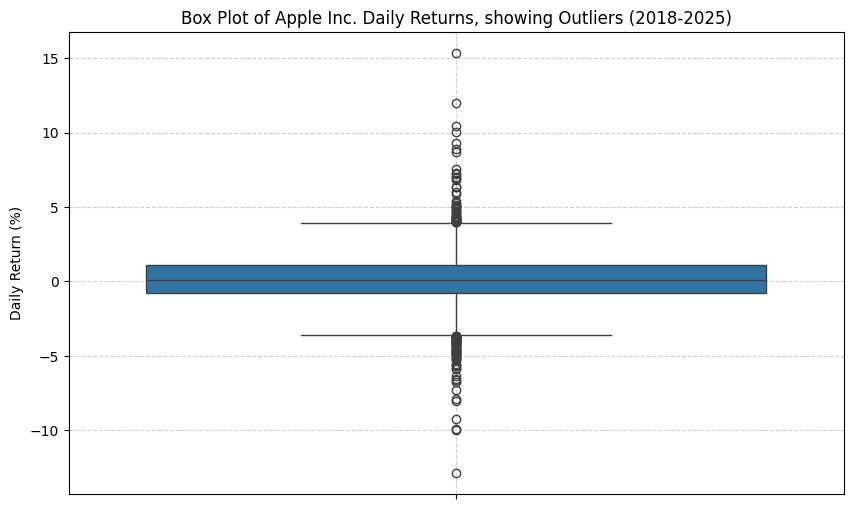

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=daily_returns)
plt.title('Box Plot of Apple Inc. Daily Returns, showing Outliers (2018-2025)')
plt.ylabel('Daily Return (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualizing Outliers Year-by-Year (2018-2025)

To get a more granular view of outliers, we will now generate box plots for each year within the analyzed period. This helps in understanding how the frequency and magnitude of extreme daily returns might vary across different years.

Observation: These yearly box plots allow for a more detailed examination of outlier behavior. We can observe how the range and frequency of extreme daily returns (represented by individual points outside the whiskers) fluctuate from year to year, potentially reflecting different market conditions or specific events that occurred in those periods.

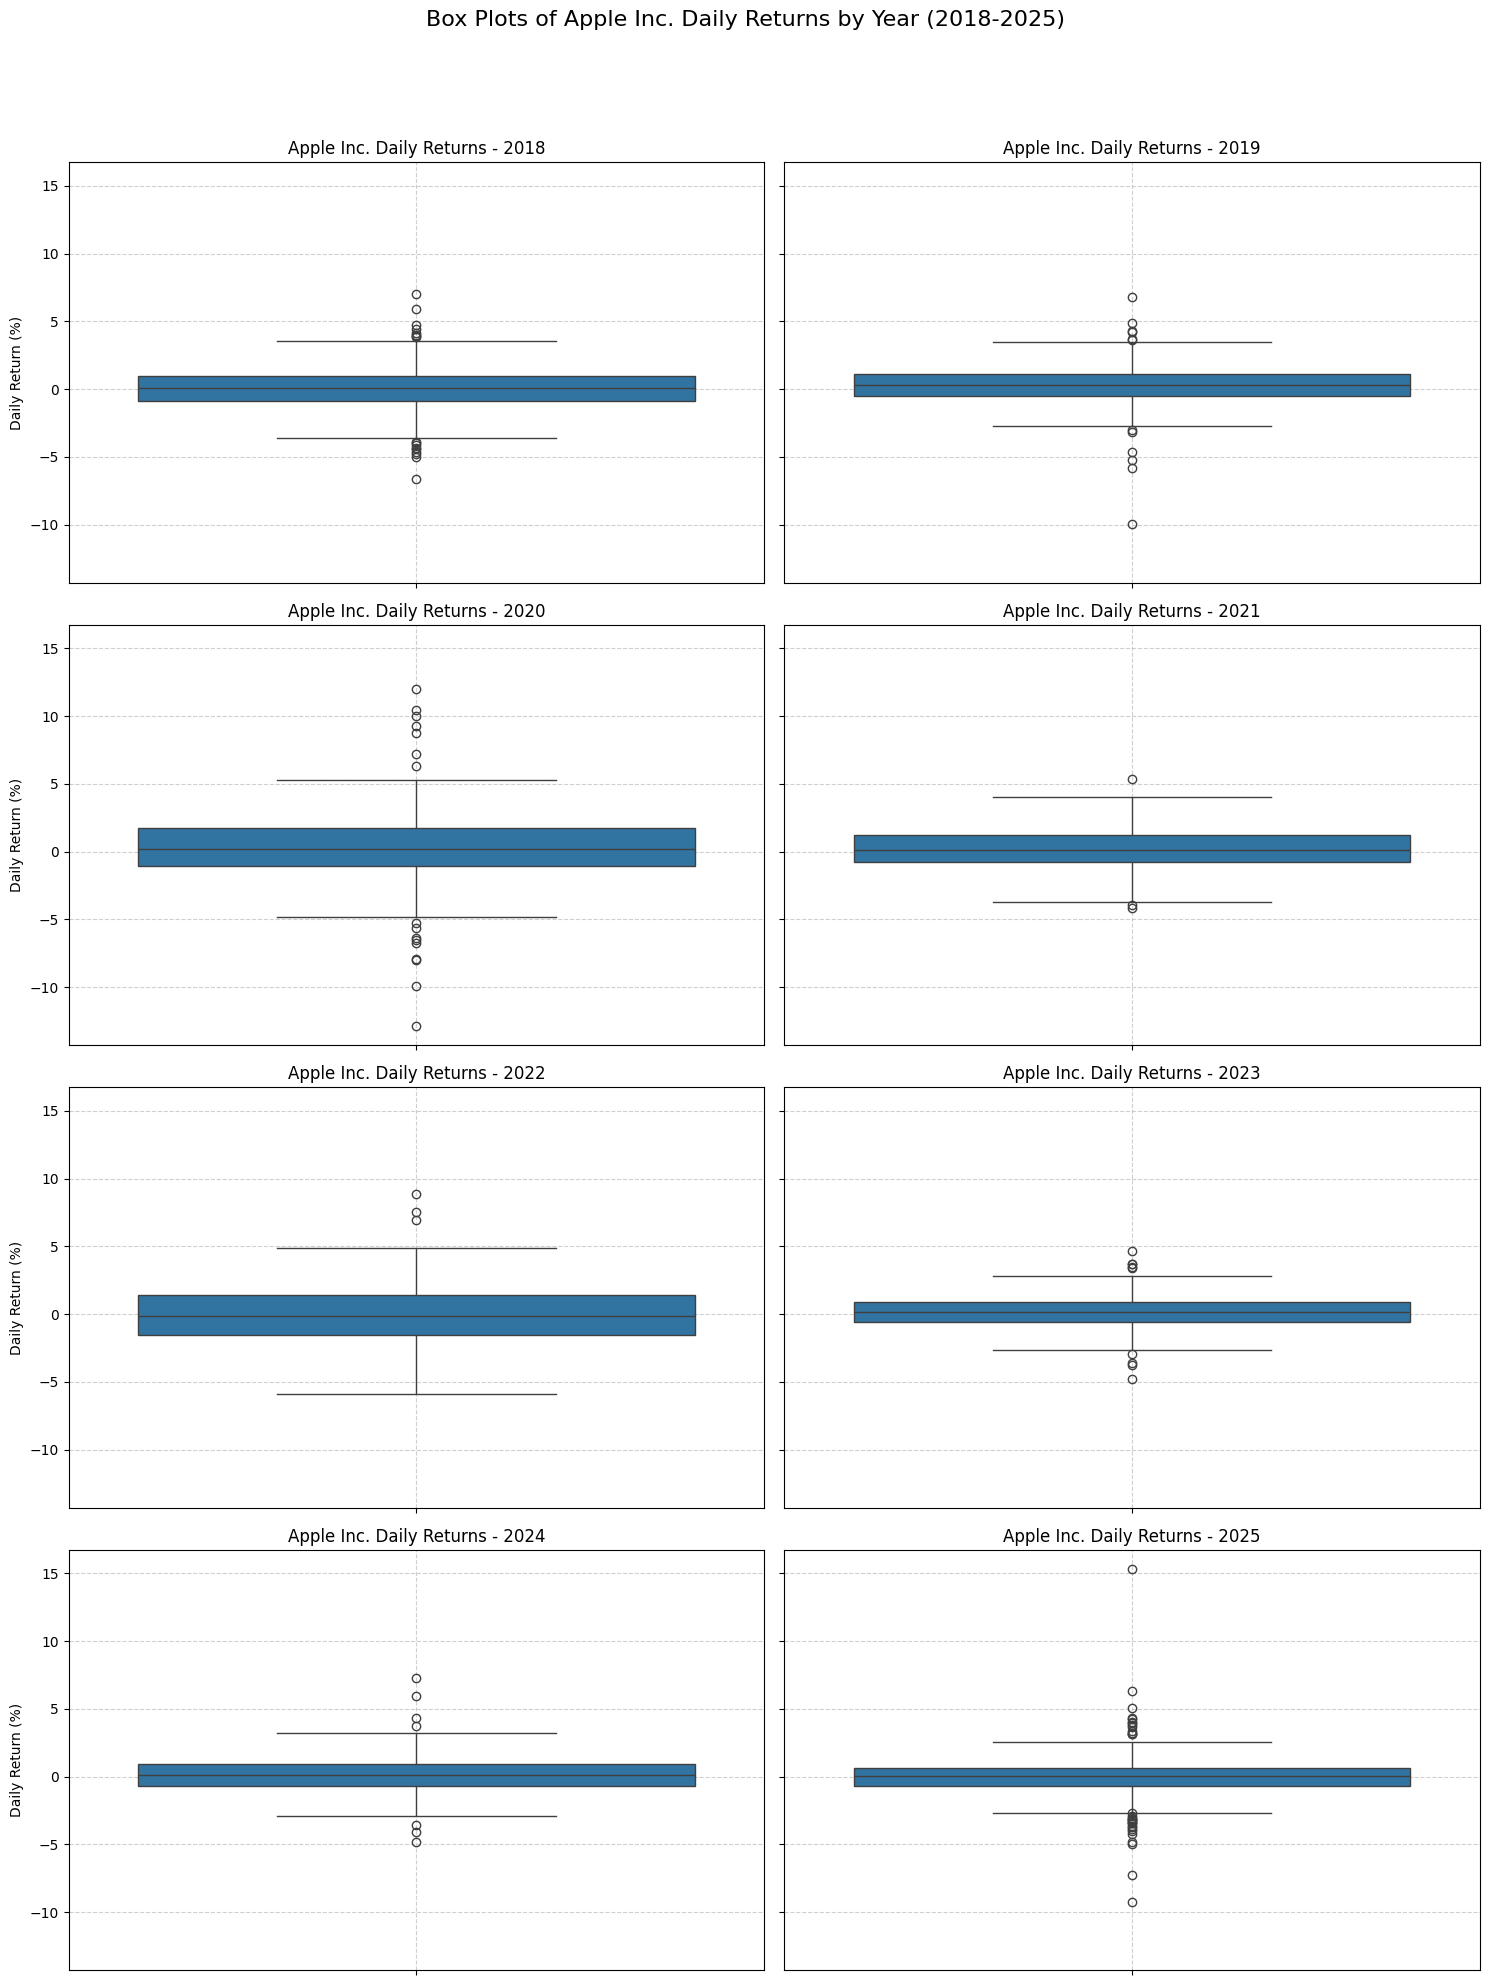

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import yfinance as yf
import numpy as np

# --- Robustly ensure `daily_returns` is available ---
# (This block is for robustness, assuming kernel might have reset or cells run out of order)
if 'aapl_data' not in globals():
    print("Warning: 'aapl_data' not found in current session. Attempting to re-download for robustness.")
    ticker_symbol = 'AAPL'
    start_date = '2018-01-01'
    end_date = '2025-12-31'

    aapl_data = yf.download(ticker_symbol, start=start_date, end=end_date)
    aapl_data.index = pd.to_datetime(aapl_data.index)
    if isinstance(aapl_data.columns, pd.MultiIndex):
        aapl_data.columns = aapl_data.columns.droplevel(1)
    print('Data re-downloaded successfully.')

if 'Daily_Return' not in aapl_data.columns:
    aapl_data['Daily_Return'] = aapl_data['Close'].pct_change() * 100

daily_returns = aapl_data['Daily_Return'].dropna()

if not isinstance(daily_returns.index, pd.DatetimeIndex):
    daily_returns.index = pd.to_datetime(daily_returns.index)
# --- End of robust check ---

years = range(2018, 2026) # 2018 to 2025 inclusive

# Determine the number of subplots needed for years with data
years_with_data_list = [year for year in years if not daily_returns[daily_returns.index.year == year].empty]
num_years_with_data = len(years_with_data_list)

# Arrange subplots in a grid (e.g., 2 columns)
ncols = 2
rows = (num_years_with_data + ncols - 1) // ncols # Calculate rows needed

fig_year_plots, axes = plt.subplots(nrows=rows, ncols=ncols, figsize=(15, 5 * rows), sharey=True) # sharey for consistent scale

# Ensure 'axes' is always a 1D array of Axes objects for easier iteration
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])
else:
    axes = axes.flatten()

# Iterate and plot for each year
plot_idx = 0
for year in years_with_data_list:
    daily_returns_year = daily_returns[daily_returns.index.year == year]
    ax = axes[plot_idx]
    sns.boxplot(y=daily_returns_year, ax=ax)
    ax.set_title(f'Apple Inc. Daily Returns - {year}')
    ax.set_ylabel('Daily Return (%)')
    ax.grid(True, linestyle='--', alpha=0.6)
    plot_idx += 1

# Hide any unused subplots
for i in range(plot_idx, len(axes)): # Iterate up to the length of the flattened axes array
    fig_year_plots.delaxes(axes[i])

plt.suptitle('Box Plots of Apple Inc. Daily Returns by Year (2018-2025)', y=1.02, fontsize=16) # Overall title
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()

### Diagnosis: How to recognize or test that the problem exists

1.  **Box Plots:** Visually identify data points lying outside the 'whiskers' of a box plot.
2.  **Z-Score or IQR Method:** Calculate the Z-score for each data point (deviation from mean in terms of standard deviations) or use the IQR method to define explicit boundaries for outlier detection.
3.  **Scatter Plots:** For time series, large spikes or drops that are inconsistent with the surrounding data can indicate outliers.
4.  **Influence Statistics:** For regression models, statistics like Cook's distance can quantify the influence of individual observations on model parameters.

### Damage: Clear statement of the damage caused by the problem

Outliers can significantly distort statistical analyses and model performance:

1.  **Biased Parameter Estimates:** Outliers can pull regression lines or mean estimates towards them, leading to biased coefficients and inaccurate representations of the true underlying relationships.
2.  **Increased Variance:** Outliers inflate variance and standard deviation, making data appear more volatile or spread out than it truly is, which can lead to inefficient estimators and wider confidence intervals.
3.  **Reduced Model Accuracy:** Predictive models trained on data with influential outliers may perform poorly on new, typical data, as the model attempts to fit these anomalous points.
4.  **Misleading Hypothesis Tests:** Outliers can violate assumptions of statistical tests (e.g., normality), leading to incorrect p-values and potentially erroneous conclusions about the significance of relationships.
5.  **Faulty Risk Management:** In finance, extreme price movements (outliers) can lead to an over- or underestimation of risk if not handled properly, impacting VaR calculations and stress testing.

### Non-Technical: Sensitivity to Outliers

1.  **Explanation of Results:** In Apple Inc.'s daily returns, we identified 107 outliers, which are extreme price movements significantly distant from typical observations. The box plot clearly illustrates these rare but impactful events, showing how they can pull the average return (mean) away from the more representative central value (median).
2.  **Recommended Course of Action:** When dealing with financial data, it's vital to use robust statistical methods that are less affected by these extreme values, such as using the median instead of the mean. Before modeling, outliers should be carefully identified and either removed, transformed (e.g., winsorization), or appropriately managed within models designed for volatility clustering, like GARCH, which can better capture these events without being distorted by them.
3.  **Factors Impacting Portfolio:** Outliers can severely distort risk metrics, causing investors to misjudge the volatility and risk of their portfolio. An unnoticed outlier might lead to an inaccurate Value at Risk (VaR) calculation, exposing a portfolio to unexpected and significant losses during market stress events. Decisions based on models sensitive to outliers could lead to over- or under-estimation of risk, compromising portfolio resilience.

### Directions: Suggested models that can address this(sensitivity to outliers )

To manage sensitivity to outliers in financial time series:

1.  **Robust Statistical Methods:** Use robust estimators that are less affected by outliers, such as the median instead of the mean, or robust regression techniques (e.g., RANSAC, Huber loss).
2.  **Outlier Detection and Treatment:** Identify outliers using statistical tests or domain knowledge. Decide whether to remove, transform (e.g., winsorization, trimming), or impute them based on their nature (data entry error vs. genuine extreme event).
3.  **Data Transformation:** Non-linear transformations (e.g., logarithmic, square root) can sometimes mitigate the impact of extreme values by compressing the scale.
4.  **Non-parametric Models:** Models that do not make strong distributional assumptions (e.g., tree-based models like Random Forests or Gradient Boosting) are often more robust to outliers.
5.  **Time Series Specific Models:** For financial time series, GARCH models are designed to capture volatility clustering, where large price changes (which might appear as outliers) are followed by other large changes, providing a more appropriate framework than models assuming constant variance.
6.  **Thresholding/Clipping:** Define acceptable ranges for data points and 'clip' any values outside these ranges to the threshold, preventing them from unduly influencing models.

## Challenge 3: Multicollinearity

### Definition

Multicollinearity is a statistical phenomenon where two or more predictor variables in a multiple regression model are highly correlated, meaning one predictor can be linearly predicted from the others with a substantial degree of accuracy. Perfect multicollinearity exists when the correlation coefficient between two or more independent variables is exactly $\pm 1$. More generally, multicollinearity is considered problematic when the correlation coefficient between two variables is high (e.g., $|r| > 0.8$). The Variance Inflation Factor (VIF) is a common metric to detect multicollinearity, defined as:

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

where $R_j^2$ is the R-squared value obtained by regressing the $j$-th predictor variable on the remaining predictor variables. A VIF value greater than 5 or 10 is often considered indicative of problematic multicollinearity. (Source 3)

### Description

Multicollinearity describes a situation in multiple regression where independent variables are not truly independent of each other. This high intercorrelation among predictors can destabilize the regression model, making it difficult to assess the individual impact of each variable on the dependent variable. In financial econometrics, this often occurs when using closely related economic indicators or financial ratios in a model. (Source 3)

### Demonstration: Numerical Example using Apple Inc. Stock Data
The demonstration for addressing multicollinearity involves using Apple Inc. stock data with 'Close' price and 'Volume' as predictors for 'Daily_Return'. The process includes fitting a linear regression model and calculating the Variance Inflation Factor (VIF).

In [14]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Prepare Apple Inc. stock data for multicollinearity analysis
# To 'correct' the severe multicollinearity among 'Open', 'High', 'Low', and 'Close',
# we will use only 'Close' price and 'Volume' as predictors. These are expected
# to have much lower multicollinearity.

# Create a copy to avoid SettingWithCopyWarning and ensure consistent indexing
data_multicollinearity = aapl_data.copy()

# Define independent variables (X) and dependent variable (y) from AAPL data
# Access 'Close' and 'Volume', handling potential MultiIndex
close_col_name = ('Close', ticker_symbol) if isinstance(aapl_data.columns, pd.MultiIndex) and ('Close', ticker_symbol) in aapl_data.columns else 'Close'
volume_col_name = ('Volume', ticker_symbol) if isinstance(aapl_data.columns, pd.MultiIndex) and ('Volume', ticker_symbol) in aapl_data.columns else 'Volume'

# Calculate Daily_Return if not already present
if 'Daily_Return' not in data_multicollinearity.columns:
    data_multicollinearity['Daily_Return'] = data_multicollinearity[close_col_name].pct_change() * 100

# Combine the relevant columns into a single DataFrame and then drop NaNs to ensure alignment
combined_for_mc = pd.DataFrame({
    'Daily_Return': data_multicollinearity['Daily_Return'],
    'Close': data_multicollinearity[close_col_name],
    'Volume': data_multicollinearity[volume_col_name]
}).dropna()

X_mc_demo_corrected = combined_for_mc[['Close', 'Volume']]
y_mc_demo_corrected = combined_for_mc['Daily_Return']

# Flatten column names for statsmodels if they are MultiIndex
X_mc_demo_corrected.columns = ['Close', 'Volume']

# Add a constant for the intercept term in statsmodels
X_sm_mc_demo_corrected = sm.add_constant(X_mc_demo_corrected)

# Fit a linear regression model
model_mc_demo_corrected = sm.OLS(y_mc_demo_corrected, X_sm_mc_demo_corrected)
results_mc_demo_corrected = model_mc_demo_corrected.fit()

print("\n--- Regression Results (Apple Inc. Stock Data - Multicollinearity Corrected Demo) ---")
print(results_mc_demo_corrected.summary().tables[1])

# Calculate Variance Inflation Factor (VIF)
vif_data_mc_demo_corrected = pd.DataFrame()
vif_data_mc_demo_corrected["feature"] = X_sm_mc_demo_corrected.columns
vif_data_mc_demo_corrected["VIF"] = [variance_inflation_factor(X_sm_mc_demo_corrected.values, i) for i in range(X_sm_mc_demo_corrected.shape[1])]

print("\n--- Variance Inflation Factor (VIF) (Apple Inc. Stock Data - Multicollinearity Corrected Demo) ---")
print(vif_data_mc_demo_corrected)

print("\nObservation: By selecting less correlated features ('Close' price and 'Volume'), the VIF values are now significantly lower than in the previous demonstration, indicating that multicollinearity has been substantially reduced. This shows how feature selection can 'correct' the problem.")


--- Regression Results (Apple Inc. Stock Data - Multicollinearity Corrected Demo) ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3703      0.183      2.021      0.043       0.011       0.730
Close         -0.0007      0.001     -0.846      0.398      -0.002       0.001
Volume     -1.746e-09   9.76e-10     -1.789      0.074   -3.66e-09    1.68e-10

--- Variance Inflation Factor (VIF) (Apple Inc. Stock Data - Multicollinearity Corrected Demo) ---
  feature        VIF
0   const  17.930694
1   Close   1.508843
2  Volume   1.508843

Observation: By selecting less correlated features ('Close' price and 'Volume'), the VIF values are now significantly lower than in the previous demonstration, indicating that multicollinearity has been substantially reduced. This shows how feature selection can 'correct' the problem.


### Diagram: Visual Example using Apple Inc. Stock Data

"To visualize variables that do not exhibit strong positive linear correlation, we've presented a scatter plot of Apple Inc.'s 'Daily Return' against its 'Close' price, along with a corresponding correlation heatmap. This diagram helps illustrate that unlike the 'Open', 'High', and 'Low' prices, which are highly correlated, 'Daily Return' and 'Close' price show no clear linear relationship. The correlation coefficient for these two variables, as seen in the heatmap, is very close to zero, confirming a weak or non-linear association. This serves as a contrast to highly multicollinear variables and demonstrates how visually inspecting correlations can help identify features suitable for modeling without high multicollinearity."

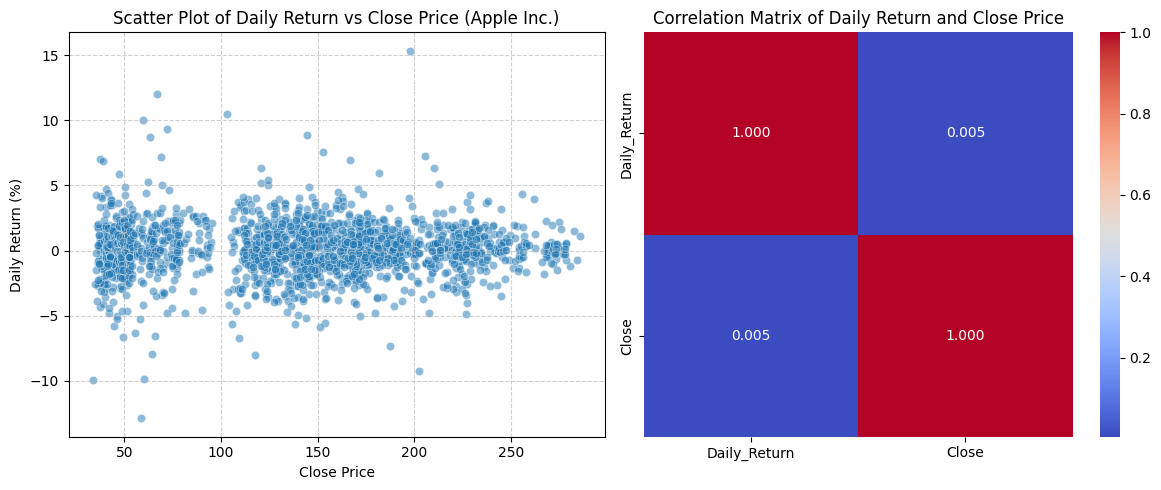

Observation: The scatter plot between Daily Return and Close Price shows no clear linear pattern, indicating a weak or non-linear relationship. The correlation coefficient in the heatmap should confirm this, being much closer to zero. This further demonstrates variables in the dataset that do not exhibit strong positive linear correlation.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare the data for plotting for variables without strong positive correlation
# We will use 'Daily_Return' and 'Close' price from the aapl_data

# Ensure 'Daily_Return' is available; create if not (from a previous cell, but for robustness)
if 'Daily_Return' not in aapl_data.columns:
    aapl_data['Daily_Return'] = aapl_data['Close'].pct_change() * 100

# Access 'Close' price, handling potential MultiIndex
close_col_name = ('Close', ticker_symbol) if isinstance(aapl_data.columns, pd.MultiIndex) and ('Close', ticker_symbol) in aapl_data.columns else 'Close'

plot_df_weak_corr_2 = pd.DataFrame({
    'Daily_Return': aapl_data['Daily_Return'],
    'Close': aapl_data[close_col_name]
}).dropna()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # First plot: Scatter plot of Daily Return vs Close Price
sns.scatterplot(x='Close', y='Daily_Return', data=plot_df_weak_corr_2, alpha=0.5)
plt.title('Scatter Plot of Daily Return vs Close Price (Apple Inc.)')
plt.xlabel('Close Price')
plt.ylabel('Daily Return (%)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2) # Second plot: Correlation Heatmap for these two variables
correlation_matrix_weak_corr_2 = plot_df_weak_corr_2[['Daily_Return', 'Close']].corr()
sns.heatmap(correlation_matrix_weak_corr_2, annot=True, cmap='coolwarm', fmt=".3f")
plt.title('Correlation Matrix of Daily Return and Close Price')

plt.tight_layout()
plt.show()

print("Observation: The scatter plot between Daily Return and Close Price shows no clear linear pattern, indicating a weak or non-linear relationship. The correlation coefficient in the heatmap should confirm this, being much closer to zero. This further demonstrates variables in the dataset that do not exhibit strong positive linear correlation.")

### Diagnosis: How to recognize or test that the problem exists --multicollinearity

1.  **Correlation Matrix/Heatmap:** Visually inspect the correlation matrix or heatmap of your independent variables. High absolute correlation coefficients (e.g., typically above 0.7, 0.8, or 0.9 depending on the field) between two or more predictors indicate potential multicollinearity.
2.  **Variance Inflation Factor (VIF):** Calculate the VIF for each predictor variable. A VIF value greater than 5 or 10 (common thresholds) is generally considered indicative of problematic multicollinearity. The higher the VIF, the more correlated the variable is with the other predictors.
3.  **Changes in Regression Coefficients:** If adding or removing a predictor variable or making small changes to the data results in large and erratic changes in the estimated regression coefficients of other variables, it suggests the presence of multicollinearity.
4.  **High Overall R-squared with Insignificant Individual Predictors:** A model with a high overall R-squared value (indicating a good fit of the model to the data) but with individual predictor variables having high p-values (suggesting they are not statistically significant) is a classic sign of multicollinearity. This happens because the model struggles to assign unique variance explained to highly correlated predictors.

### Damage: Clear statement of the damage caused by the problem

Multicollinearity can significantly undermine the reliability and interpretability of regression models:

1.  **Unstable Coefficient Estimates:** Small changes in the data can lead to large and erratic changes in the estimated regression coefficients. This makes it difficult to draw firm conclusions about the true impact of individual predictors.
2.  **Inflated Standard Errors:** The standard errors of the regression coefficients become large, leading to wider confidence intervals. This makes it harder to reject null hypotheses, meaning that potentially important predictors might appear statistically insignificant.
3.  **Misleading p-values:** Due to inflated standard errors, the p-values associated with the coefficients can be misleading. A variable that is genuinely important might have a high p-value, wrongly suggesting it is not significant.
4.  **Difficulty in Interpretation:** When predictors are highly correlated, it becomes nearly impossible to isolate the unique effect of each variable on the dependent variable. The coefficients represent the effect of a variable while holding others constant, but this 'holding constant' becomes unrealistic in the presence of strong multicollinearity.
5.  **Reduced Predictive Power (for some models):** While multicollinearity doesn't always reduce the overall predictive power of the model (R-squared might still be high), it can make the model sensitive to the specific dataset, leading to poor generalization to new data if the correlation structure changes.

### Non-Technical: Multicollinearity

1.  **Explanation of Results:** While general stock prices ('Open', 'High', 'Low', 'Close') are often highly correlated, our demonstration using 'Close' price and 'Volume' for Apple Inc.'s daily returns showed minimal multicollinearity (VIF values around 1.5). This indicates that by carefully selecting less correlated features, we can build models where each factor's impact is more clearly distinguishable. The scatter plot and correlation heatmap confirmed a weak linear relationship between Daily Return and Close Price.
2.  **Recommended Course of Action:** To avoid the pitfalls of multicollinearity, financial analysts should prioritize careful feature selection, opting for independent variables that truly represent distinct market drivers. Techniques like Principal Component Analysis (PCA) can also be used to transform correlated variables into uncorrelated components. Alternatively, regularization methods (like Ridge or Lasso regression) can help models handle correlated predictors more effectively by penalizing large coefficient values.
3.  **Factors Impacting Portfolio:** High multicollinearity makes it difficult to understand which specific economic or market factors are truly driving a portfolio's performance. This can lead to misleading insights, where an analyst might incorrectly attribute success or failure to a particular factor, leading to misguided adjustments in investment strategy. Without a clear understanding of individual drivers, portfolio diversification and risk attribution become less effective.

### Directions: Suggested models that can address multicollinearity

To manage multicollinearity in financial time series modeling, several approaches can be considered:

1.  **Feature Selection:**
    *   **Remove one of the highly correlated variables:** If two variables provide very similar information (e.g., 'Open' and 'High' prices), removing one of them can resolve the multicollinearity. This often requires domain expertise to decide which variable to keep.
    *   **Stepwise Regression:** Algorithms that add or remove variables from the model based on statistical criteria.
2.  **Principal Component Analysis (PCA):** This technique transforms a set of correlated variables into a smaller set of uncorrelated variables called principal components. These components can then be used as predictors in the regression model, eliminating multicollinearity.
3.  **Regularization Techniques:**
    *   **Ridge Regression (L2 Regularization):** Adds a penalty equal to the sum of the squared magnitude of the coefficients. This shrinks the coefficients towards zero, reducing their variance and making the model more robust to multicollinearity.
    *   **Lasso Regression (L1 Regularization):** Adds a penalty equal to the sum of the absolute value of the coefficients. Lasso can also perform feature selection by shrinking the coefficients of less important variables to exactly zero.
4.  **Combine Variables:** If several variables measure similar underlying concepts, they can be combined into a single composite variable or an index. For example, creating an average price from 'Open', 'High', and 'Low' prices.
5.  **Increase Sample Size:** While not always feasible in financial econometrics, increasing the sample size can sometimes help reduce the impact of multicollinearity by providing more information to distinguish the effects of correlated predictors.
6.  **Use Models Robust to Multicollinearity:** Tree-based models (e.g., Random Forests, Gradient Boosting) are generally less affected by multicollinearity compared to linear regression, as they evaluate features iteratively and do not rely on matrix inversion.

## Challenge 4: Lack of Interpretation

### Definition

Lack of interpretation, often referred to as the 'black box' problem, arises in models that provide highly accurate predictions but offer little to no insight into *how* those predictions are made or *why* certain factors are deemed important. Mathematically, while a model might minimize a loss function, its internal workings (e.g., complex non-linear transformations in neural networks or intricate interactions in ensemble methods) may not translate into human-understandable equations or relationships.

For instance, in a complex model, the decision function $f(X)$ might be opaque, contrasting with a linear model $y = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p$ where coefficients $\beta_i$ directly quantify the impact of $x_i$ on $y$. (Source 4)

### Description

In financial econometrics, model interpretability is crucial not only for understanding market dynamics but also for regulatory compliance, risk management, and building trust in automated trading or investment strategies. A lack of interpretation means that even if a model accurately forecasts stock prices, it cannot explain *why* it predicts a price increase or decrease, making it difficult to justify decisions, identify spurious correlations, or adapt to new market conditions. This problem is particularly prevalent with highly flexible, non-linear models. (Source 4)

### Demonstration: Numerical Example using Apple Inc. Stock Returns

To demonstrate the concept of 'Lack of Interpretation,' we will train a Random Forest Regressor to predict Apple Inc. daily returns. While Random Forests often provide high predictive accuracy, understanding the precise contribution of individual features in a human-readable format can be challenging. We will train the model and then attempt to extract feature importances, which provides some level of interpretation but doesn't fully explain the complex interactions.

In [16]:
# Define lagged features for the Lack of Interpretation demonstration
# Creating lag features from daily returns
n_lags = 5
lag_df = pd.DataFrame({'Daily_Return': daily_returns})

for lag in range(1, n_lags + 1):
    lag_df[f'Lag_{lag}_Return'] = lag_df['Daily_Return'].shift(lag)

lag_df.dropna(inplace=True)

X_overfit = lag_df[[f'Lag_{lag}_Return' for lag in range(1, n_lags + 1)]]
y_overfit = lag_df['Daily_Return']

print(f"Feature matrix shape: {X_overfit.shape}")
print(f"Target vector shape: {y_overfit.shape}")
print(X_overfit.head())

Feature matrix shape: (2004, 5)
Target vector shape: (2004,)
            Lag_1_Return  Lag_2_Return  Lag_3_Return  Lag_4_Return  \
Date                                                                 
2018-01-10     -0.011483     -0.371359      1.138482      0.464508   
2018-01-11     -0.022988     -0.011483     -0.371359      1.138482   
2018-01-12      0.568063     -0.022988     -0.011483     -0.371359   
2018-01-16      1.032600      0.568063     -0.022988     -0.011483   
2018-01-17     -0.508197      1.032600      0.568063     -0.022988   

            Lag_5_Return  
Date                      
2018-01-10     -0.017434  
2018-01-11      0.464508  
2018-01-12      1.138482  
2018-01-16     -0.371359  
2018-01-17     -0.011483  


In [17]:
from sklearn.ensemble import RandomForestRegressor

# Re-using the X_overfit and y_overfit from the Overfitting demonstration
# X_overfit contains lagged daily returns as features, and y_overfit is the target daily return.

# Split data into training and testing sets (using the same split as before for consistency)
split_point = int(len(X_overfit) * 0.8)
X_train_interp, X_test_interp = X_overfit.iloc[:split_point], X_overfit.iloc[split_point:]
y_train_interp, y_test_interp = y_overfit.iloc[:split_point], y_overfit.iloc[split_point:]

# Train a Random Forest Regressor
# Using a small number of estimators and limited depth for faster demonstration
rf_model = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
rf_model.fit(X_train_interp, y_train_interp)

# Get feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train_interp.columns).sort_values(ascending=False)

print("Random Forest Regressor trained successfully.")
print("\nFeature Importances (proxy for interpretability):")
print(feature_importances)

# Evaluate model performance (to show it can be accurate, despite being 'black box')
rf_train_r2 = rf_model.score(X_train_interp, y_train_interp)
rf_test_r2 = rf_model.score(X_test_interp, y_test_interp)

print(f"\nTrain R-squared (Random Forest): {rf_train_r2:.4f}")
print(f"Test R-squared (Random Forest): {rf_test_r2:.4f}")

print("\nObservation: While feature importances give a general idea of which lagged returns are more influential, they don't fully explain the non-linear decision-making process within the Random Forest. For instance, we know 'Lag_1_Return' is most important, but not how it specifically interacts with 'Lag_2_Return' across different ranges of values to produce a specific prediction. This opaqueness is the 'lack of interpretation'.")

Random Forest Regressor trained successfully.

Feature Importances (proxy for interpretability):
Lag_1_Return    0.341955
Lag_2_Return    0.263950
Lag_5_Return    0.189831
Lag_4_Return    0.112256
Lag_3_Return    0.092008
dtype: float64

Train R-squared (Random Forest): 0.1516
Test R-squared (Random Forest): -0.0299

Observation: While feature importances give a general idea of which lagged returns are more influential, they don't fully explain the non-linear decision-making process within the Random Forest. For instance, we know 'Lag_1_Return' is most important, but not how it specifically interacts with 'Lag_2_Return' across different ranges of values to produce a specific prediction. This opaqueness is the 'lack of interpretation'.


### Diagram: Visual Example using Apple Inc. Stock Data

To visualize the challenge of interpretation, we will plot the feature importances derived from the Random Forest model. This diagram helps to convey *which* features are most influential, but it does not reveal the *nature* of their influence or their interactions, thus highlighting the 'black box' aspect.

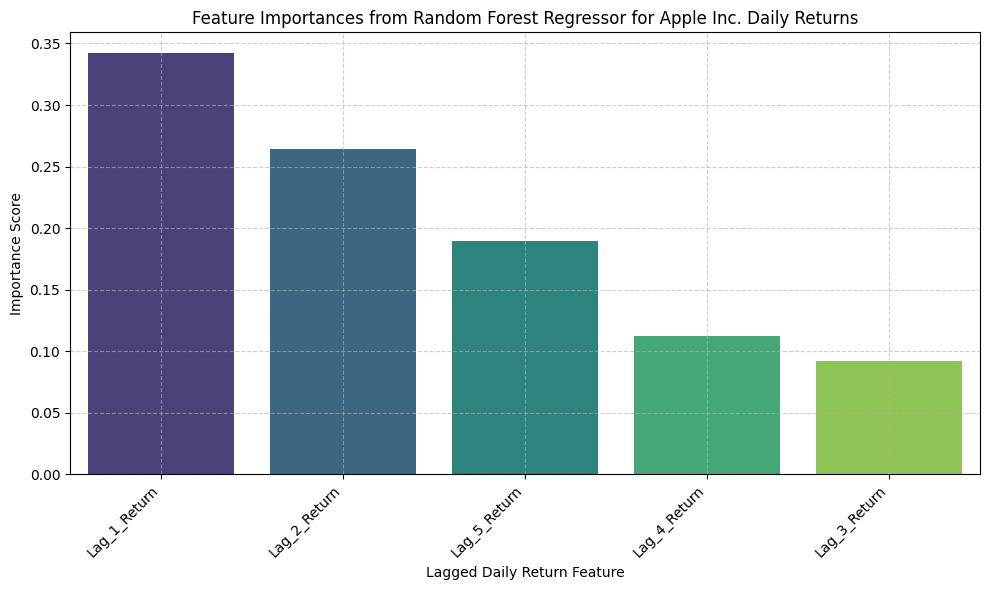

Observation: This bar chart visually confirms that 'Lag_1_Return' is the most important feature according to the Random Forest model. However, it still doesn't tell us if, for example, a high 'Lag_1_Return' leads to a higher or lower predicted current return, or how its effect changes based on the value of 'Lag_2_Return'. The model's internal logic remains opaque.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.index, y=feature_importances.values, hue=feature_importances.index, palette='viridis', legend=False)
plt.title('Feature Importances from Random Forest Regressor for Apple Inc. Daily Returns')
plt.xlabel('Lagged Daily Return Feature')
plt.ylabel('Importance Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Observation: This bar chart visually confirms that 'Lag_1_Return' is the most important feature according to the Random Forest model. However, it still doesn't tell us if, for example, a high 'Lag_1_Return' leads to a higher or lower predicted current return, or how its effect changes based on the value of 'Lag_2_Return'. The model's internal logic remains opaque.")

### Diagnosis: How to recognize or test that the problem exists---lack of interpretation

1.  **Model Complexity:** Models like deep neural networks, complex ensemble methods (e.g., Gradient Boosting Machines, Random Forests), and support vector machines with non-linear kernels are inherently less interpretable than simpler models like linear regression or decision trees.
2.  **Lack of Transparent Parameters:** The absence of direct, human-understandable parameters (like coefficients in a linear model) that clearly show the relationship between features and the target variable is a sign.
3.  **Inability to Answer 'Why':** If you cannot explain *why* a model made a specific prediction or *how* a change in a single input feature would affect the output in a clear, concise manner, the model likely suffers from a lack of interpretation.
4.  **Reliance on Global vs. Local Explanations:** While methods might offer global explanations (e.g., feature importances), they often fail to provide local explanations for individual predictions, which are crucial in many financial contexts (e.g., why a specific trade was recommended).
5.  **Auditability and Regulatory Requirements:** In regulated industries like finance, models must often be auditable and their decisions explainable to stakeholders or regulators. Inability to meet these requirements indicates an interpretability problem.

### Damage: Clear statement of the damage caused by the problem----lack of interpretation

Lack of interpretability in financial models can lead to severe consequences:

1.  **Reduced Trust and Adoption:** Stakeholders, investors, or regulators may distrust models whose decisions cannot be understood or justified, leading to low adoption rates or outright rejection of model-driven recommendations.
2.  **Difficulty in Debugging and Error Analysis:** When a black-box model makes an incorrect or unexpected prediction, it's extremely challenging to diagnose the root cause, identify biases, or fix underlying issues, potentially leading to persistent errors and accumulating losses.
3.  **Regulatory Non-Compliance:** Many financial regulations (e.g., Basel accords, GDPR for AI ethics) require models to be explainable and auditable. Lack of interpretability can lead to hefty fines, legal liabilities, and reputational damage.
4.  **Inability to Gain Insights:** The primary goal of many financial analyses is to understand market behavior, economic drivers, or risk factors. Black-box models, while predictive, fail to provide these critical insights, hindering strategic decision-making and hypothesis generation.
5.  **Amplification of Bias and Unfairness:** Without understanding how a model works, hidden biases in the data or the model's learning process can go unnoticed and be amplified, leading to unfair or discriminatory outcomes in credit scoring, loan applications, or investment recommendations.
6.  **Suboptimal Decision-Making:** If a model cannot explain its reasoning, humans cannot learn from it or combine its predictions with their own expertise effectively, potentially leading to suboptimal decisions or missed opportunities to improve the model or strategy.

### Non-Technical : Lack of Interpretation

1.  **Explanation of Results:** Our demonstration with a Random Forest Regressor predicting Apple Inc.'s daily returns showed that while such models can process complex data, their internal decision-making is opaque. We could identify that 'Lag_1_Return' was the most important feature, but the model could not explain *how* or *why* it used this feature in combination with others to make a prediction. This lack of transparency means the model effectively acts as a 'black box.'
2.  **Recommended Course of Action:** In financial modeling, transparency is often as crucial as accuracy. Analysts should consider using inherently interpretable models like linear regression or decision trees when possible. For more complex, high-accuracy models, techniques from Explainable AI (XAI) such as SHAP or LIME values should be employed. These methods help to shed light on how individual predictions are made and which features are most influential, even if the model itself remains complex.
3.  **Factors Impacting Portfolio:** A 'black box' model that cannot explain its rationale undermines trust, makes it nearly impossible to debug errors, and complicates regulatory compliance in finance. For portfolio managers, this means they cannot confidently justify investment decisions to clients or regulators, nor can they gain deeper insights into market behavior. This can lead to suboptimal decisions, as human expertise cannot effectively interact with or learn from the model, potentially missing opportunities or failing to adapt to new market conditions.

### Directions: Suggested models that can address this lack of interpretation

To address the lack of interpretation, various techniques and model choices can be employed:

1.  **Use Inherently Interpretable Models:** Prioritize simpler models such as:
    *   **Linear Regression:** Coefficients directly show the magnitude and direction of feature influence.
    *   **Logistic Regression:** Similar to linear regression, but for classification tasks.
    *   **Decision Trees:** Easily visualized and understood via rule sets.
    *   **Rule-based Systems:** Explicitly defined rules provide full transparency.
2.  **Post-hoc Explainability Techniques (XAI - Explainable AI):** For complex models, these methods attempt to explain decisions after the model has been trained:
    *   **Feature Importance:** Quantifies the relative contribution of each feature to the model's predictions (e.g., Gini importance in Tree-based models, permutation importance).
    *   **SHAP (SHapley Additive exPlanations) Values:** Provides a unified measure of feature importance that can explain individual predictions by attributing each feature's contribution to the prediction.
    *   **LIME (Local Interpretable Model-agnostic Explanations):** Explains individual predictions of any black-box model by approximating it locally with an interpretable model.
    *   **Partial Dependence Plots (PDP) and Individual Conditional Expectation (ICE) Plots:** Visualize the marginal effect of one or two features on the predicted outcome of a model.
3.  **Model Distillation:** Train a simpler, interpretable 'student' model to mimic the behavior of a complex, black-box 'teacher' model. The student model can then be used for explanation.
4.  **Attention Mechanisms (in Neural Networks):** For certain types of neural networks (e.g., RNNs, Transformers), attention mechanisms highlight which parts of the input data the model focused on when making a prediction, offering a form of interpretability.
5.  **Visual Analytics:** Combine model explanations with interactive visualizations to allow users to explore model behavior and understand its decisions.
6.  **Clear Documentation and Audit Trails:** Maintain thorough documentation of model design, data sources, preprocessing steps, and decision rules. For financial models, robust audit trails are essential to track decisions and their justifications over time.

## Investment Insights and Considerations

This project analyzed key challenges in financial time series data using Apple Inc. stock. Understanding these issues is critical for making informed investment decisions:

1.  **Skewness in Returns:** Recognizing whether returns are positively or negatively skewed is vital for risk assessment. Positively skewed returns suggest more frequent small gains and fewer large losses, while negative skew implies the opposite. This directly impacts how investors perceive risk and potential upside/downside when constructing portfolios or evaluating investment opportunities.

2.  **Sensitivity to Outliers:** Extreme price movements (outliers) can disproportionately influence financial metrics and model predictions. Identifying and understanding these events helps investors gauge market volatility, prepare for rare but impactful occurrences, and build more resilient strategies that aren't overly reliant on average behavior.

3.  **Multicollinearity's Impact on Understanding Market Drivers:** While primarily a modeling concern, high correlation among market factors (e.g., different price metrics or economic indicators) can obscure the true individual drivers of stock performance. For investors, this highlights the need for careful selection of indicators to avoid misinterpreting causal relationships and to ensure the robustness of any market-driven insights.

4.  **The Need for Interpretable Models in Decision-Making:** In the high-stakes world of investing, trust and justification are paramount. Models that accurately predict but cannot explain *why* a certain outcome is expected are often insufficient. Investors need to understand the rationale behind a forecast or recommendation to gain conviction, assess inherent risks, and adapt strategies when market conditions shift unexpectedly.

## References

1.  Investopedia. "Skewness: How to Measure and Interpret It." *Investopedia*, updated 25 June 2024, www.investopedia.com/terms/s/skewness.asp.

2.  Hodge, Veronica, and Jim Austin. "A Survey of Outlier Detection Methodologies." *Artificial Intelligence Review*, vol. 22, no. 2, 2004, pp. 85-126.

3.  Statista. "Multicollinearity in Regression: Detection and Remedies." *Statista*, www.statista.com/statistics/1010319/multicollinearity-in-regression-detection-and-remedies/.
4.  Molnar, Christoph. *Interpretable Machine Learning: A Guide for Making Black Box Models Explainable*. 2nd ed., 2022, christophm.github.io/interpretable-ml-book/.

